In [1]:
import json

import gc_utils
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import cluster as cl

import halo_analysis as halo
import utilities as ut
import gizmo_analysis as gizmo

In [2]:
sim = "m12i"
# sim_dir = "/Users/z5114326/Documents/simulations/"
sim_dir = "/Volumes/Expansion/simulations/"
fire_dir = sim_dir + sim + "/" + sim + "_res7100"

proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
proc_data = h5py.File(proc_file, "r")  # open processed data file

snap_file = fire_dir + "/snapshot_times.txt"
snap_data = pd.read_table(snap_file, comment="#", header=None, sep=r"\s+")
snap_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]

snap_pub_file = sim_dir + "/snapshot_times_public.txt"
snap_pub = pd.read_table(snap_pub_file, comment="#", header=None, sep=r"\s+")
snap_pub.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]

data_file = sim_dir + sim + "/gc_groups.json"
with open(data_file, "r") as file:
    gc_dict = json.load(file)

kap_dat_file = sim_dir + sim + "/galaxy_kinematics.json"
with open(kap_dat_file, "r") as file:
    kappa_dat = json.load(file)

sim_code_file = sim_dir + "simulation_codes.json"
with open(sim_code_file, "r") as file:
    sim_codes = json.load(file)

In [6]:
snap_lim = 30

sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
# sim_lst = ["m12i"]
sim_dict = {sim: {"num_mergers": [], "mass": []} for sim in sim_lst}

for sim in sim_lst:
    main_halo = sim_codes[sim]["halo"]
    Ob = sim_codes[sim]["Ob"]
    Om = sim_codes[sim]["Om"]
    fb = Ob / Om

    fire_dir = sim_dir + sim + "/" + sim + "_res7100"
    halt = halo.io.IO.read_tree(simulation_directory=fire_dir)

    for snap in range(snap_lim, 600 + 1):
        halo_tid = gc_utils.get_halo_prog_at_snap(halt, main_halo, snap)
        idx_init = np.where(halt["tid"] == halo_tid)[0][0]
        idx = idx_init
        idx_lst = []
        for i in range(0, halt["progenitor.number"][idx_init]):
            if i == 0:
                idx = halt["progenitor.main.index"][idx]
            else:
                idx = halt["progenitor.co.index"][idx]

            if halt["am.phantom"][idx] == 0:
                idx_lst.append(idx)

        sim_dict[sim]["num_mergers"].append(len(idx_lst) - 1)

        dm_mass = halt["mass"][idx_init]
        mass = dm_mass / (1 - fb)
        sim_dict[sim]["mass"].append(mass)


# in utilities.simulation.Snapshot():
* reading:  Volumes/Expansion/simulations/m12b/m12b_res7100/snapshot_times.txt

* read 27985526 halos from:  Volumes/Expansion/simulations/m12b/m12b_res7100/halo/rockstar_dm/catalog_hdf5/tree.hdf5


# in utilities.simulation.Snapshot():
* reading:  Volumes/Expansion/simulations/m12c/m12c_res7100/snapshot_times.txt

* read 64931480 halos from:  Volumes/Expansion/simulations/m12c/m12c_res7100/halo/rockstar_dm/catalog_hdf5/tree.hdf5


# in utilities.simulation.Snapshot():
* reading:  Volumes/Expansion/simulations/m12f/m12f_res7100/snapshot_times.txt

* read 38620514 halos from:  Volumes/Expansion/simulations/m12f/m12f_res7100/halo/rockstar_dm/catalog_hdf5/tree.hdf5


# in utilities.simulation.Snapshot():
* reading:  Volumes/Expansion/simulations/m12i/m12i_res7100/snapshot_times.txt

* read 17859038 halos from:  Volumes/Expansion/simulations/m12i/m12i_res7100/halo/rockstar_dm/catalog_hdf5/tree.hdf5


# in utilities.simulation.Snapshot():
* reading:  V

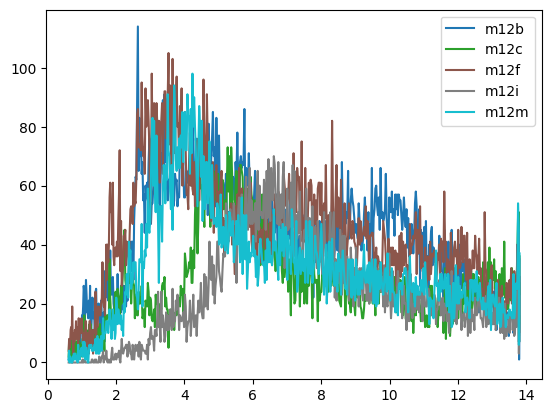

In [4]:
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(sim_lst))]

bin_size = 0.5

for j, sim in enumerate(sim_lst):
    x = snap_data[snap_data["index"] >= snap_lim]["time_Gyr"]
    y = sim_dict[sim]["num_mergers"]

    plt.plot(x, y, c=colors[j], label=sim)

plt.legend()

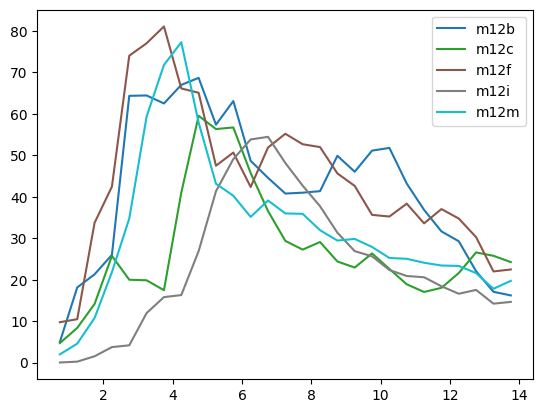

In [5]:
bin_size = 0.5

# sim_lst = ["m12m"]

for j, sim in enumerate(sim_lst):
    x = snap_data[snap_data["index"] >= snap_lim]["time_Gyr"]
    y = sim_dict[sim]["num_mergers"]

    # Define bins of 0.25 Gyr
    bins = np.arange(0, np.max(x) + bin_size, bin_size)

    # Digitize x into bins
    inds = np.digitize(x, bins)

    y_avg = []
    t_bin_centers = []
    for i in range(1, len(bins)):
        mask = inds == i
        if np.any(mask):
            y_avg.append(np.mean(np.array(y)[mask]))
            t_bin_centers.append((bins[i] + bins[i - 1]) / 2)

    y_avg = np.array(y_avg)
    t_bin_centers = np.array(t_bin_centers)

    grad = np.gradient(y_avg, t_bin_centers)

    plt.plot(t_bin_centers, y_avg, c=colors[j], label=sim)
    # plt.plot(t_bin_centers, grad, c=colors[j], label = sim)

plt.legend()

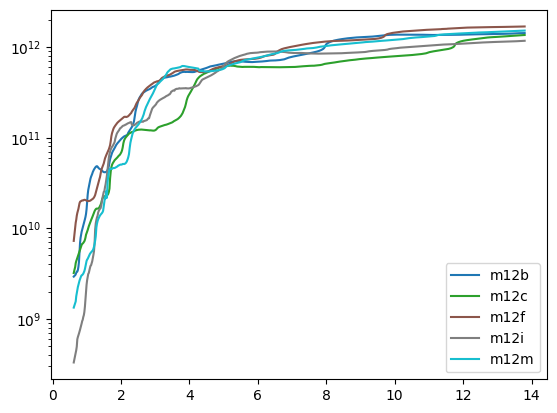

In [9]:
for j, sim in enumerate(sim_lst):
    x = snap_data[snap_data["index"] >= snap_lim]["time_Gyr"]
    y = sim_dict[sim]["mass"]

    plt.plot(x, y, c=colors[j], label=sim)

plt.legend()
plt.yscale("log")